In [1]:
# !pip install scikit-learn

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [3]:
train_dataset = pd.read_csv('train_data.csv', sep=';')
test_dataset = pd.read_csv('test_data.csv', sep=';')
train_dataset.head()

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,24,41,373,638,38,462,391,26,6,242,...,112,19,40,40,41,39,13,40,1,135
1,1364,508,1016,889,796,833,693,297,260,244,...,57,42,53,40,39,73,39,53,1,14
2,575,1177,1051,452,975,330,649,23,31,9,...,112,54,44,99,22,26,26,65,1,14
3,622,670,711,120,169,149,321,411,251,411,...,18,1,3,90,90,82,86,61,1,15
4,1342,1571,1102,964,923,362,297,574,491,349,...,46,53,51,72,88,73,9,30,1,15


In [4]:
modelos = [["Diag 01 Principal (cod+des)", "Diag 02 Secundario (cod+des)", "Proced 01 Principal (cod+des)", "Proced 02 Secundario (cod+des)", "Proced 03 Secundario (cod+des)", "Proced 04 Secundario (cod+des)", "Proced 05 Secundario (cod+des)"],
 ["GRD"]]

In [5]:
model_target = train_dataset["GRD"]
X_train = train_dataset[modelos[0]]

In [6]:
X_test = test_dataset[modelos[0]]

In [7]:
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
model = LogisticRegression(max_iter=3500)
model.fit(X_train_scaled, model_target)

LogisticRegression(max_iter=3500)

In [9]:
y_pred = model.predict(X_test_scaled)
y_true = test_dataset["GRD"]

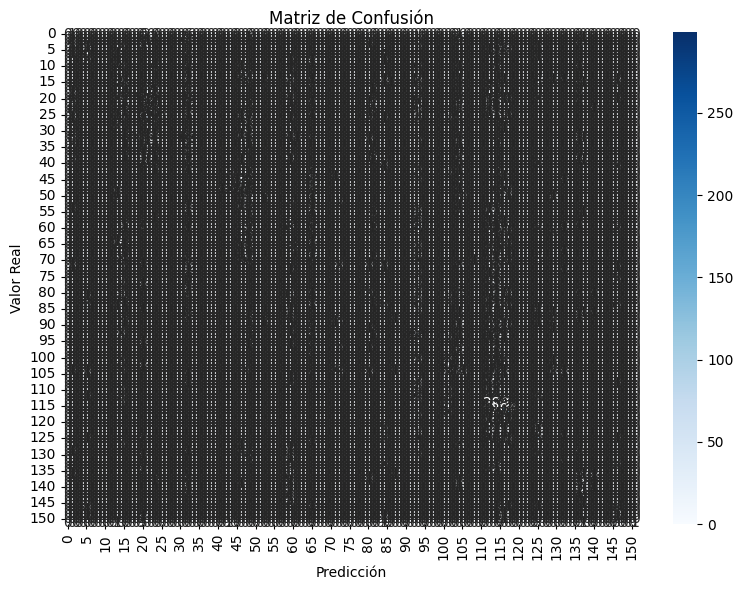

In [10]:
conf_matrix = confusion_matrix(y_true, y_pred)

# Crear gráfico heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')

plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.tight_layout()
plt.show()

In [11]:
# Métricas
acc = accuracy_score(y_true, y_pred) * 100
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100  # O 'macro' si todas las clases tienen igual importancia
rec = recall_score(y_true, y_pred, average='weighted', zero_division=0) *100

print(f"\nAccuracy:  {acc:.2f}%")
print(f"Precisión: {prec:.2f}%")
print(f"Recall:    {rec:.2f}%")


Accuracy:  33.71%
Precisión: 25.62%
Recall:    33.71%


<ipython-input-12-79026096eeb8>:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


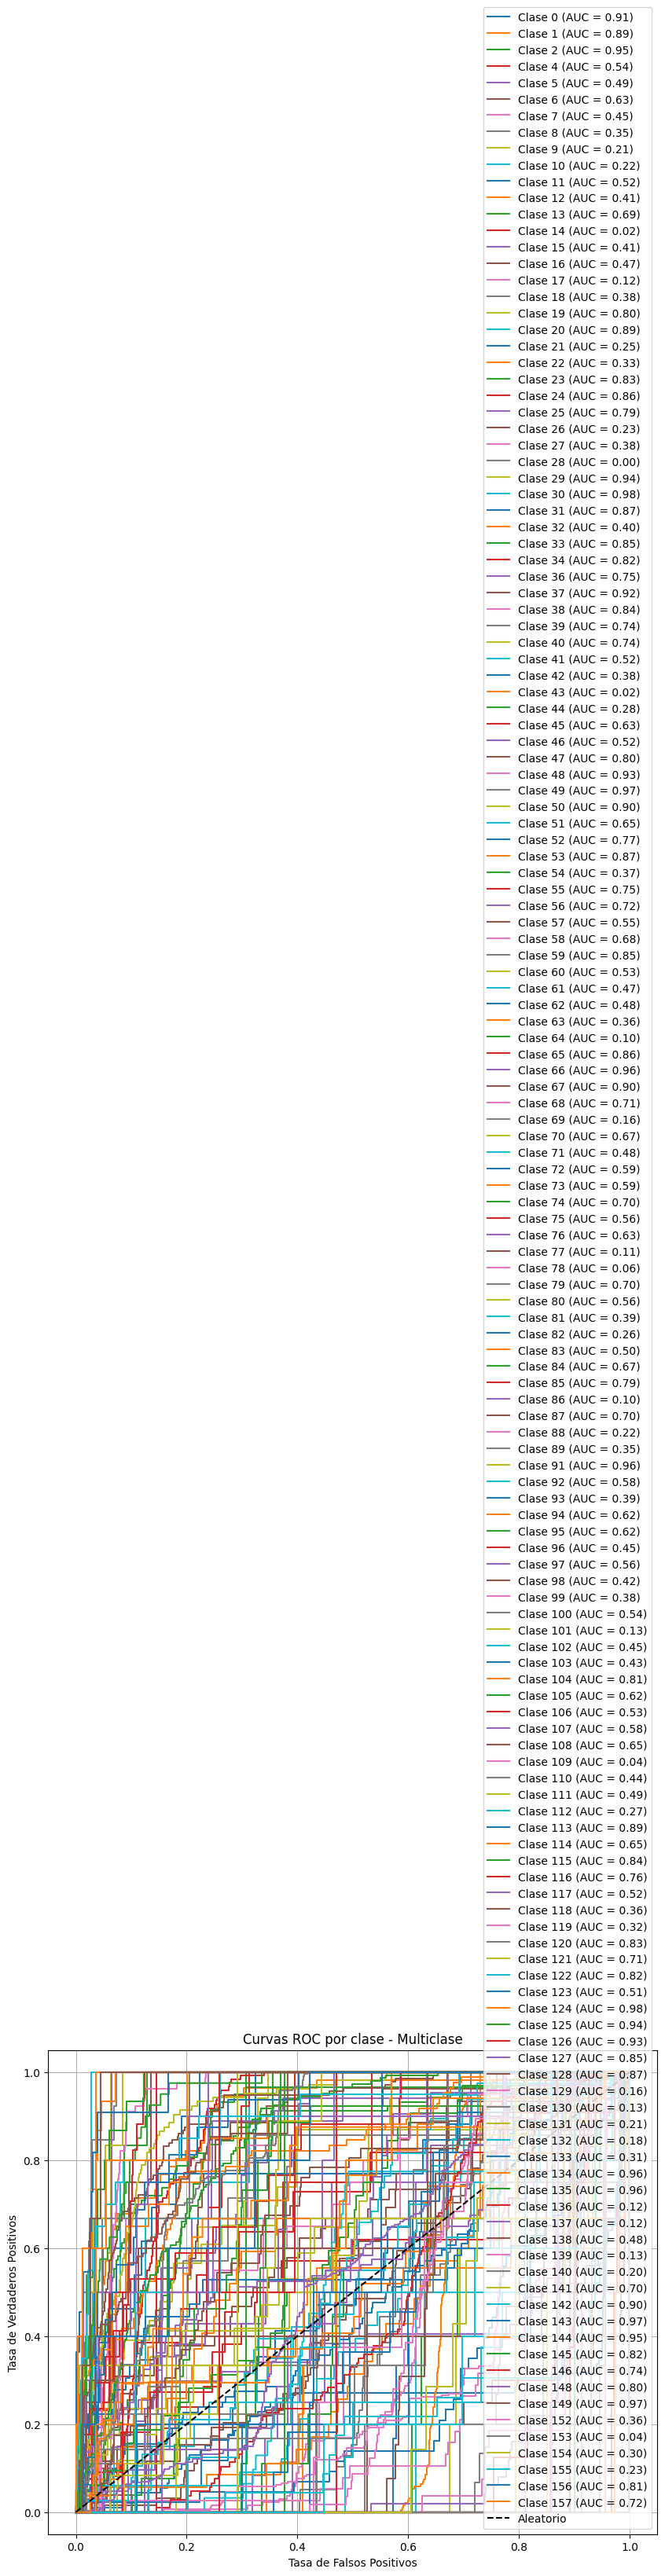

In [12]:
# Clases únicas ordenadas
classes = sorted(np.unique(y_true))

# 1. Convertir y_true a one-hot encoding (binarización)
y_true_bin = label_binarize(y_true, classes=classes)
n_classes = y_true_bin.shape[1]

# 2. Obtener probabilidades de cada clase
y_score = model.predict_proba(X_test_scaled)

# 3. Calcular curva ROC y AUC por clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Graficar todas las curvas ROC
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Clase {classes[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Aleatorio")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curvas ROC por clase - Multiclase")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Model con todo

In [13]:
columns_name = train_dataset.columns.tolist()
columns_name.remove("GRD")

In [14]:
model_target = train_dataset["GRD"]
X_train = train_dataset[columns_name]
X_test = test_dataset[columns_name]

In [15]:
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train_scaled, model_target)

LogisticRegression(max_iter=5000)

In [17]:
y_pred = model.predict(X_test_scaled)
y_true = test_dataset["GRD"]

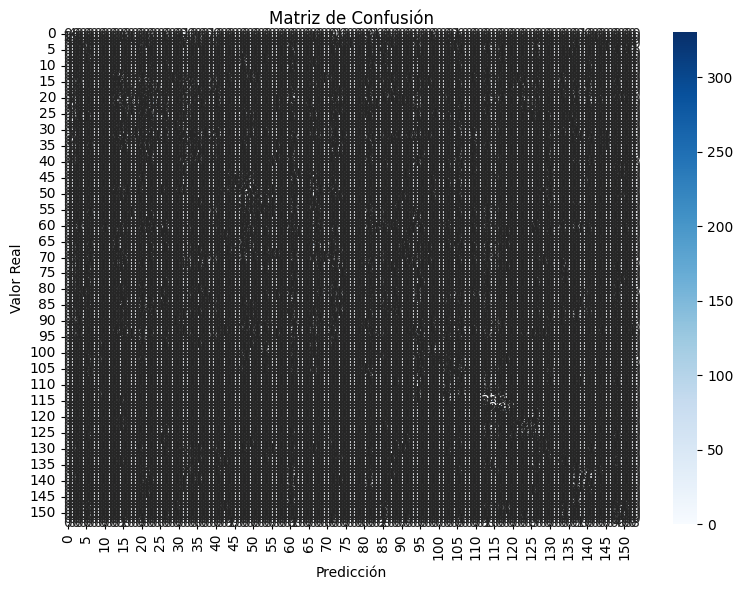

In [18]:
conf_matrix = confusion_matrix(y_true, y_pred)

# Crear gráfico heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')

plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.tight_layout()
plt.show()

In [19]:
# Métricas
acc = accuracy_score(y_true, y_pred) * 100
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100  # O 'macro' si todas las clases tienen igual importancia
rec = recall_score(y_true, y_pred, average='weighted', zero_division=0) *100

print(f"\nAccuracy:  {acc:.2f}%")
print(f"Precisión: {prec:.2f}%")
print(f"Recall:    {rec:.2f}%")


Accuracy:  40.92%
Precisión: 36.56%
Recall:    40.92%
